In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from inputs_for_plots import *

In [2]:
def prepare_error_dataframe(ols_est, errors_list, column_names):
    """Creates a DataFrame with all error values in a long format."""
    df_list = [pd.DataFrame(np.abs(ols_est), columns=["Biased OLS"])]
    for errors, col_name in zip(errors_list, column_names):
        df_list.append(pd.DataFrame(errors["error"], columns=[col_name]))
    return pd.concat(df_list, axis=1)


## Plot increase in confounding

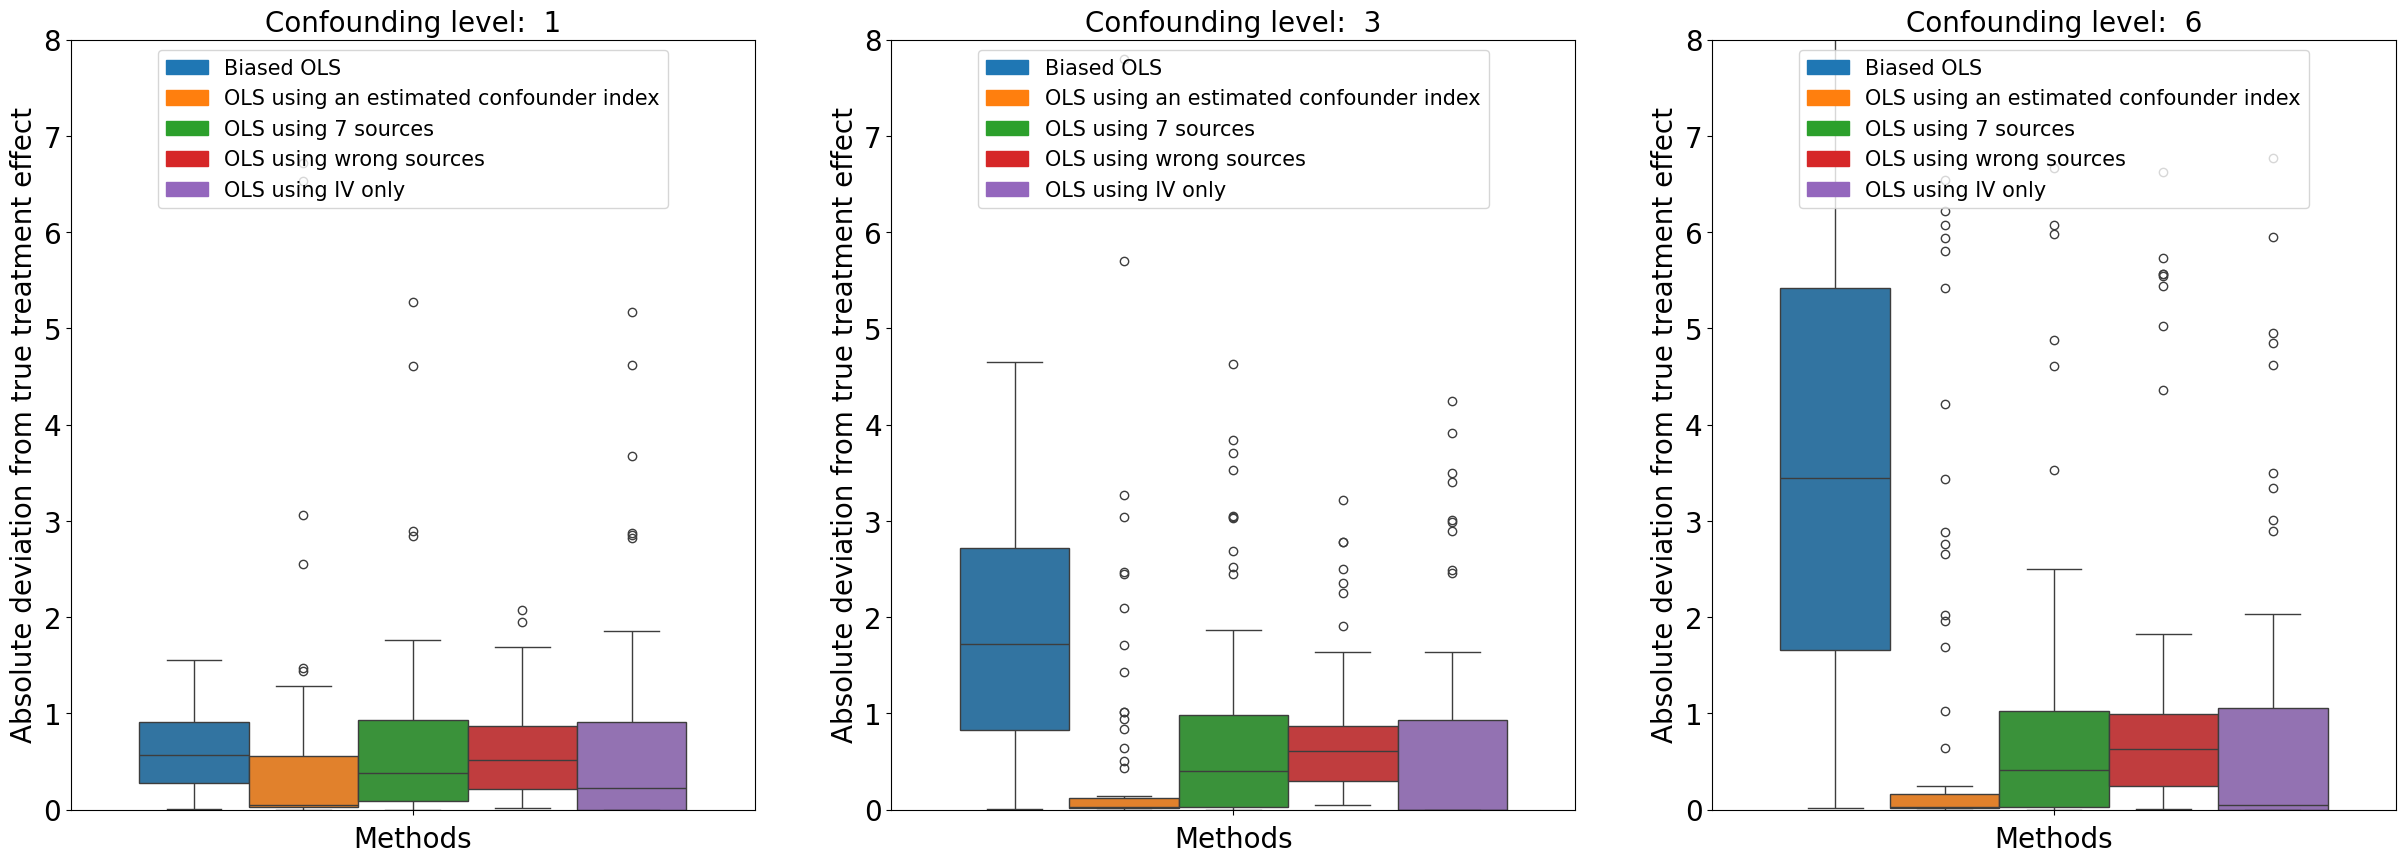

In [3]:
def main_plot(confounder_levels):
    """Generates plots for different confounder levels."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(30, 10))
    
    for i, level in enumerate(confounder_levels):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_confounding_levels/data/", name=f"true_mixing_large_conf_{level}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_confounding_levels/data/", name=f"data_obs_large_conf_{level}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
        
        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_cn_{level}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_cn_{level}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_cn_{level}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_cn_{level}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources, errors_nonsense,errors_iv_only ], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[level] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], level, "Confounding level")
    
    plt.show()
    return method_summary

# Example usage
confounder_levels = [1, 3, 6]
method_summary = main_plot(confounder_levels)


In [4]:
print_method_summary(method_summary)

Level 1
       Biased OLS  OLS using an estimated confounder index  \
RMSE     0.688614                                 1.832042   
MAE      0.585996                                 0.612863   
STD      0.687864                                 1.823154   
Cases  100.000000                                87.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              1.565732                 0.731443           1.662679  
MAE               0.753034                 0.592085           0.755280  
STD               1.565423                 0.708569           1.662184  
Cases            97.000000                89.000000          90.000000  
Level 3
       Biased OLS  OLS using an estimated confounder index  \
RMSE     2.060265                                 5.535587   
MAE      1.753669                                 1.565944   
STD      2.057837                                 5.495530   
Cases  100.000000                                87.000000  

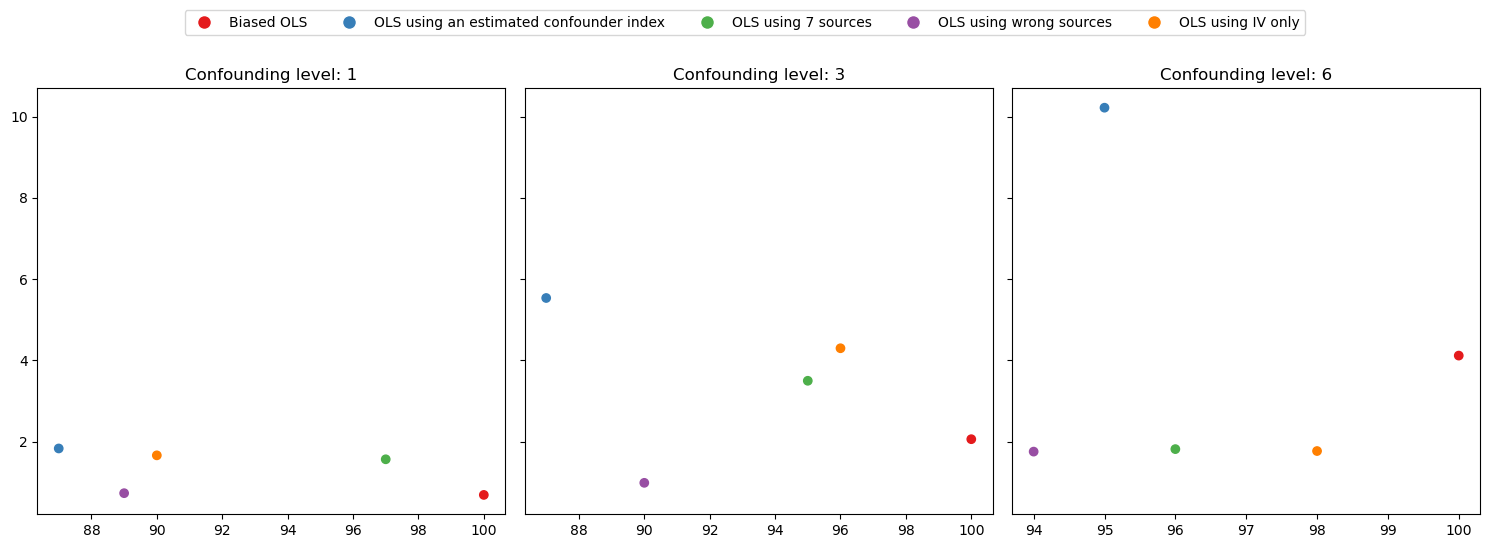

In [5]:
plot_cases_vs_performance(method_summary, "rmse", "Confounding level")

## Plot different number of covariates

FileNotFoundError: [Errno 2] No such file or directory: '../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_number_of_covs_3.csv'

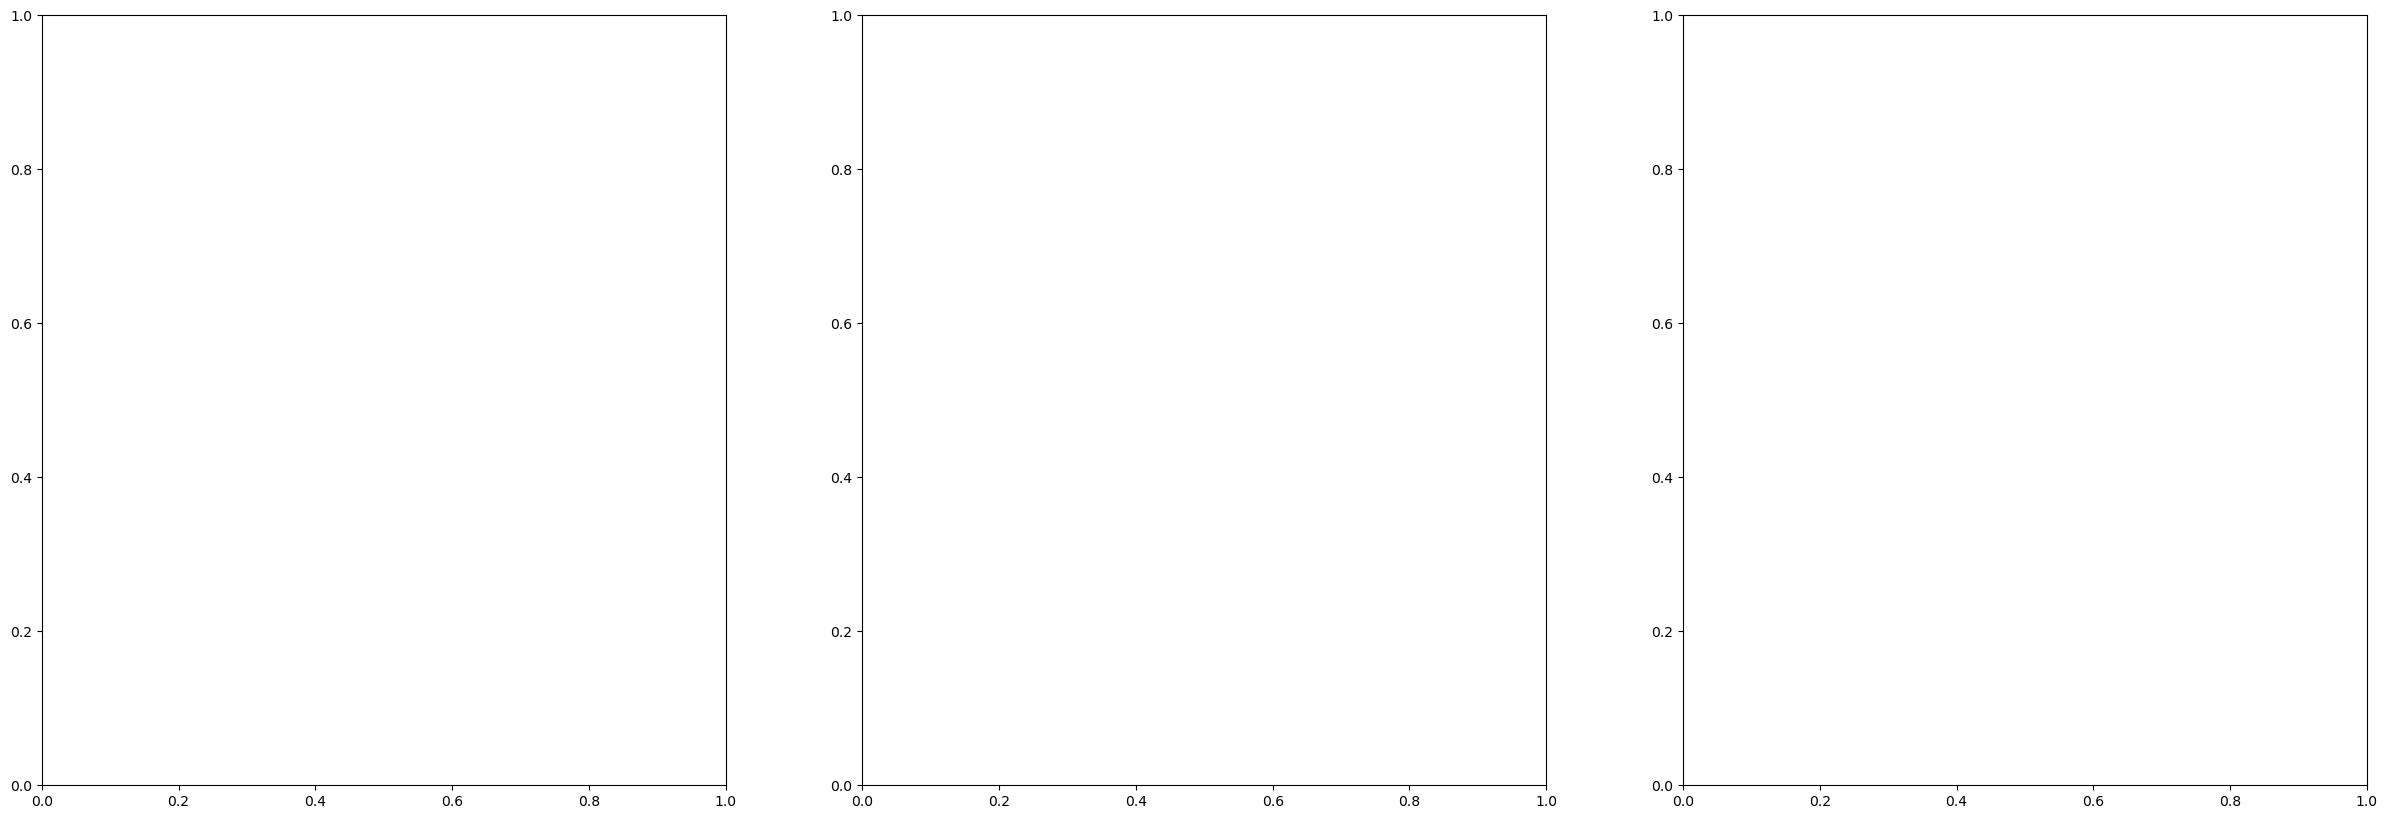

In [6]:
def main_plot(number_of_covariates):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(number_of_covariates), figsize=(30, 10))
    
    for i, covs in enumerate(number_of_covariates):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_numbers_of_covariates/data/", name=f"true_mixing_covs_{covs}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_numbers_of_covariates/data/", name=f"data_obs_covs_{covs}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)


        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_number_of_covs_{covs}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_number_of_covs_{covs}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_number_of_covs_{covs}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_number_of_covs_{covs}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[covs] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], covs, "Number of covariates")
    
    plt.show()
    return method_summary

# Example usage
number_of_covariates = [3, 6, 9]
method_summary = main_plot(number_of_covariates)




In [ ]:
print_method_summary(method_summary)

In [ ]:
plot_cases_vs_performance(method_summary, "rmse", "Number of covariates")

## Plot different sample sizes

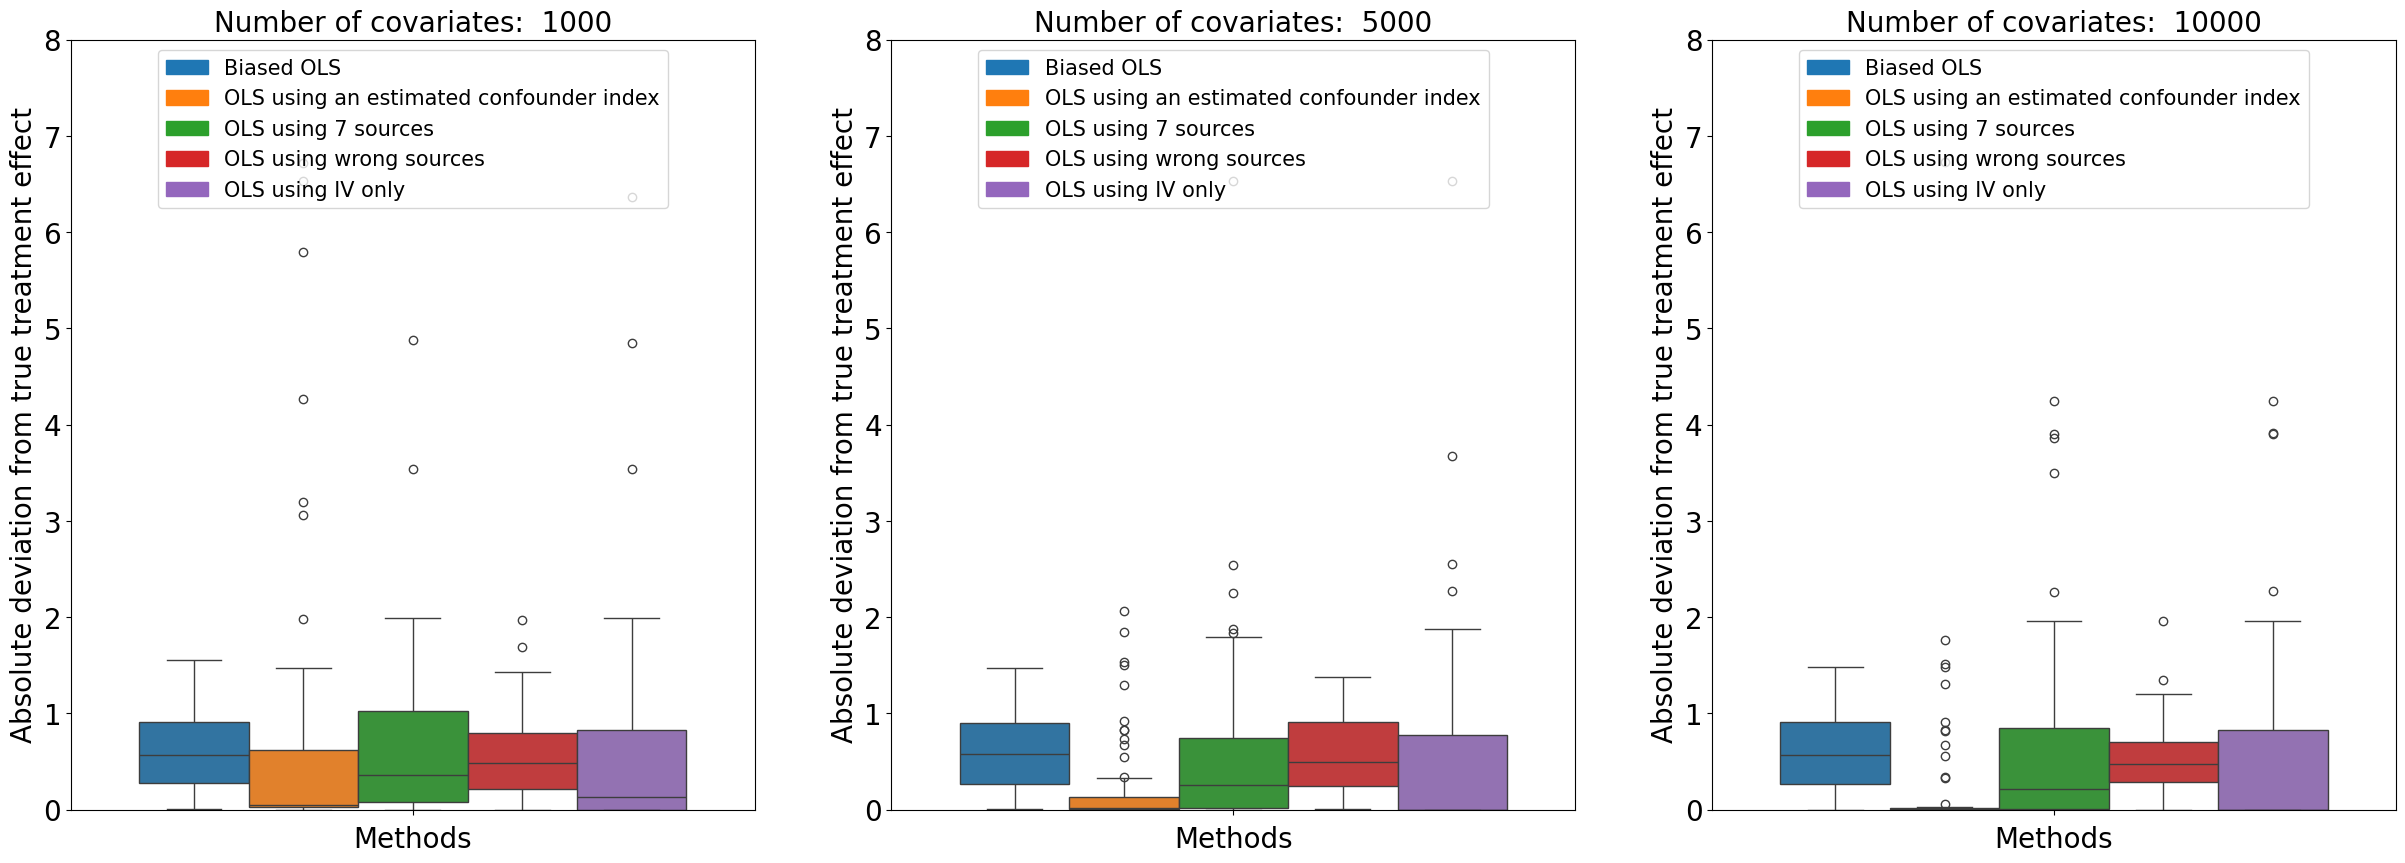

In [20]:
def main_plot(ns):
    """Generates plots for different number of sample sizes."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(ns), figsize=(30, 10))
    
    for i, n in enumerate(ns):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/differen_sample_sizes/data/", name=f"true_mixing_n:{n}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/differen_sample_sizes/data/", name=f"data_obs_n:{n}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)


        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_n:{n}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_n:{n}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_n:{n}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_n:{n}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[n] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], n, "Number of covariates")
    
    plt.show()
    return method_summary

# Example usage
ns = [1000, 5000, 10000]
method_summary = main_plot(ns)




In [21]:
print_method_summary(method_summary)

Level 1000
       Biased OLS  OLS using an estimated confounder index  \
RMSE     0.688614                                 1.452720   
MAE      0.585996                                 0.608864   
STD      0.687864                                 1.449405   
Cases  100.000000                                85.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              0.988199                 0.676536           1.164792  
MAE               0.632940                 0.544164           0.590979  
STD               0.979425                 0.670809           1.161690  
Cases            98.000000                87.000000          90.000000  
Level 5000
       Biased OLS  OLS using an estimated confounder index  \
RMSE     0.692705                                 2.208206   
MAE      0.587399                                 0.588257   
STD      0.691709                                 2.140965   
Cases  100.000000                                67.00

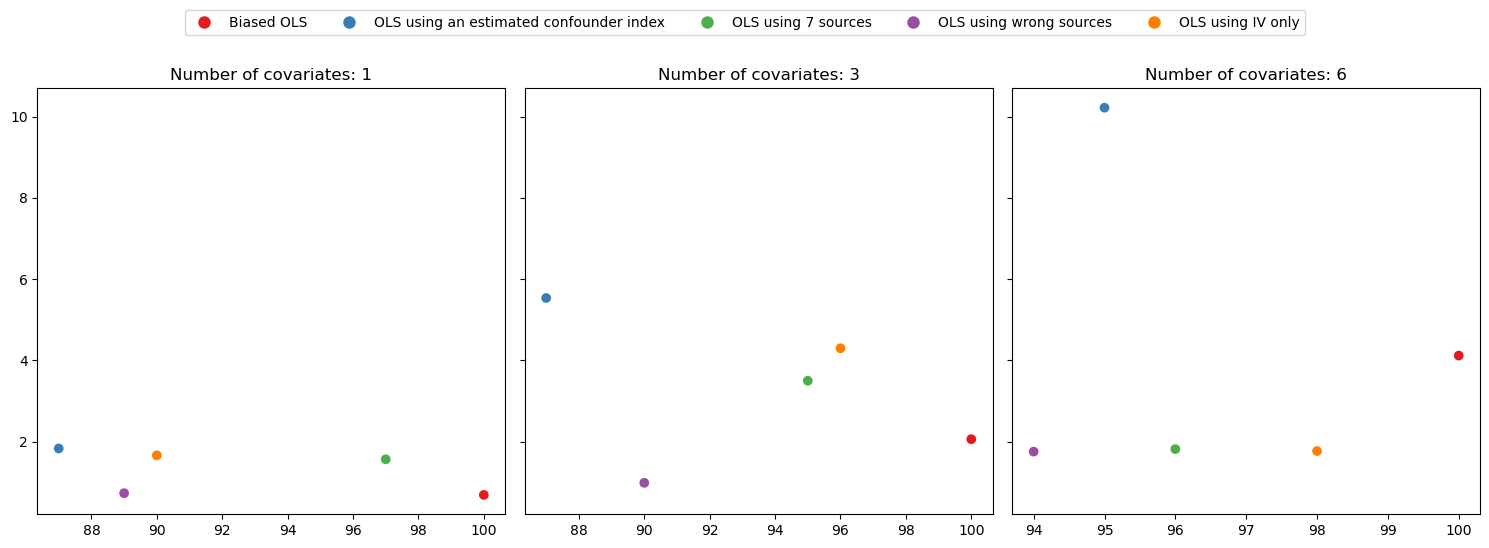

In [7]:
plot_cases_vs_performance(method_summary, "rmse", "Number of covariates")

 # Plot bounded treatment effect

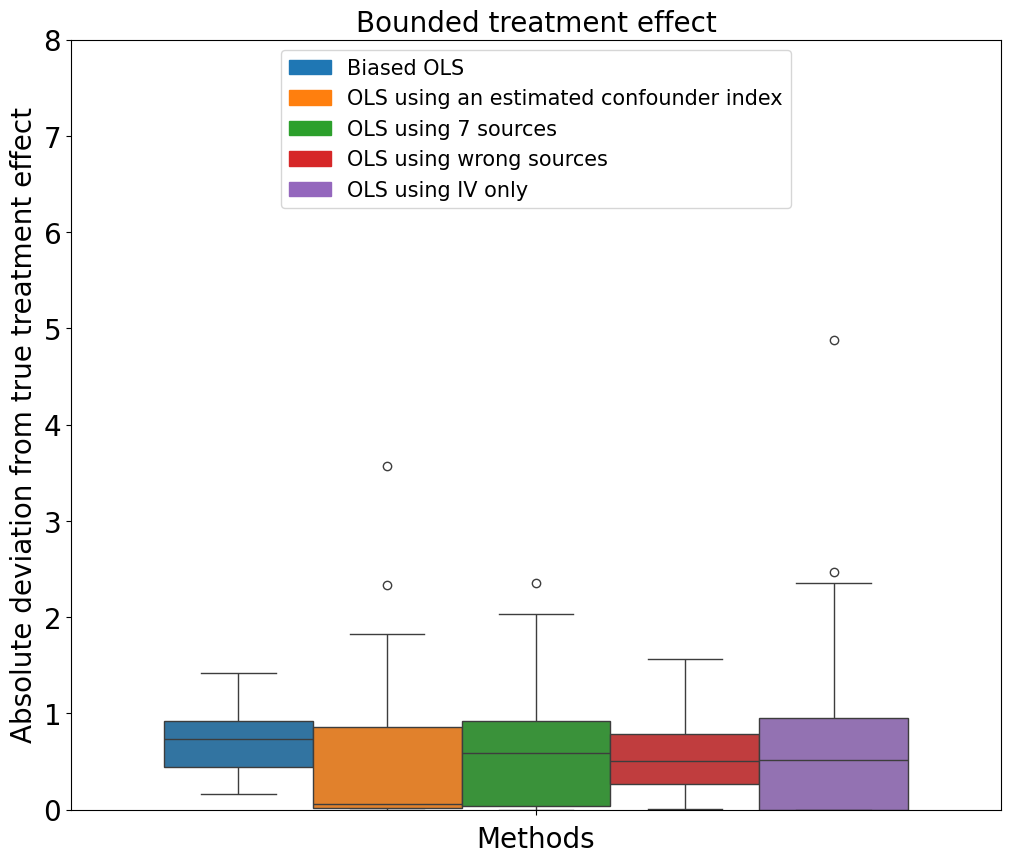

Bounded treatment effect
                                             RMSE       MAE       STD
Biased OLS                               0.779054  0.713521  0.777512
OLS using an estimated confounder index  0.784616  0.473511  0.784616
OLS using 7 sources                      0.841481  0.626732  0.835685
OLS using wrong sources                  0.660312  0.559038  0.659115
OLS using IV only                        0.957798  0.605432  0.957542


In [8]:
def plot_errors_bounded(err, rmse, mae, std,ax):
    """Creates boxplots and adds legend with RMSE, MAE, and STD."""
    df_long = err.melt(var_name="variable", value_name="value").dropna()
    sns.boxplot(data=df_long, y="value", hue="variable", ax=ax)
    
    ax.set_title(f"Bounded treatment effect", fontsize=20)
    ax.set_ylabel("Absolute deviation from true treatment effect", fontsize=20)
    ax.set_xlabel("Methods", fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_ylim((0,8))
    palette = sns.color_palette(n_colors=err.shape[1])

    handles = [
        mpatches.Patch(color=palette[i], label=f"{err.columns[i]}")
        for i in range(len(err.columns))
    ]
    ax.legend(handles=handles, loc="upper center", fontsize=15)
true_treatment = get_true_treatment_effect(path="data_generation/bounded_treatment_effect/data/", name="true_mixing_init_flipp_")
ols_est = calculate_ols_estimate(path=f"data_generation/bounded_treatment_effect/data/", name= "data_obs_init_flipp_")
ols_est = np.array(ols_est) - np.array(true_treatment)




errors_confounder = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_bounded_treatment.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
errors_7_sources = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_bounded_treatment.csv", "estimated_treatment_on_sources", "true_treatment_effect")
errors_nonsense = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_bounded_treatment.csv", "mistaken_scheme", "true_treatment_effect")
errors_iv_only = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_bounded.csv", "iv_only_effect", "true_treatment_effect")

rmse, mae, std = [], [], []
gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
gather_statistics(errors_confounder, rmse, mae, std)
gather_statistics(errors_7_sources, rmse, mae, std)
gather_statistics(errors_nonsense, rmse, mae, std)
gather_statistics(errors_iv_only, rmse, mae, std)

err = prepare_error_dataframe(ols_est,  [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
no_of_cases = {col: 100 - err[col].isna().sum() for col in err.columns}
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plot_errors_bounded(err, rmse, mae, std, ax)  
plt.show()

# print metric summary
print("Bounded treatment effect")
print(pd.DataFrame({"RMSE": rmse, "MAE": mae, "STD": std}, index=err.columns))

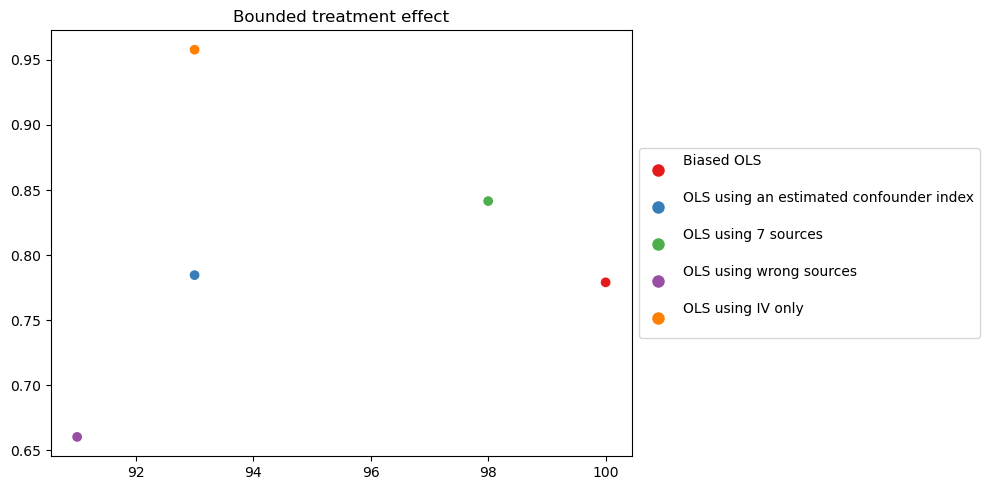

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharey=True)



methods = no_of_cases.keys()
cases = no_of_cases.values()
palette = sns.color_palette("Set1", len(methods))
ax.scatter(cases, rmse, c=palette, label=methods)

ax.set_title("Bounded treatment effect")    

legend_labels = list(methods)
legend_colors = palette[:len(legend_labels)]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in legend_colors]

# Add line breaks after each method in the legend
legend_labels = [label + '\n' for label in legend_labels]

# Position the legend to the left of the plot
ax.legend(handles, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

plt.tight_layout()
plt.show()
